# Multi-Agent Strategy Exploration

Analyze different multi-agent learning strategies

In [1]:
import sys
import os

# Determine the project root dynamically
def get_project_root():
    current_dir = os.getcwd()
    
    # Check if we're in the notebooks directory
    if os.path.basename(current_dir) == 'notebooks':
        return os.path.dirname(current_dir)
    
    return current_dir

# Add project root to Python path
project_root = get_project_root()
sys.path.insert(0, project_root)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.environment import ScarseGridEnv
from src.agents import MultiAgentQLearning


Using device: cuda


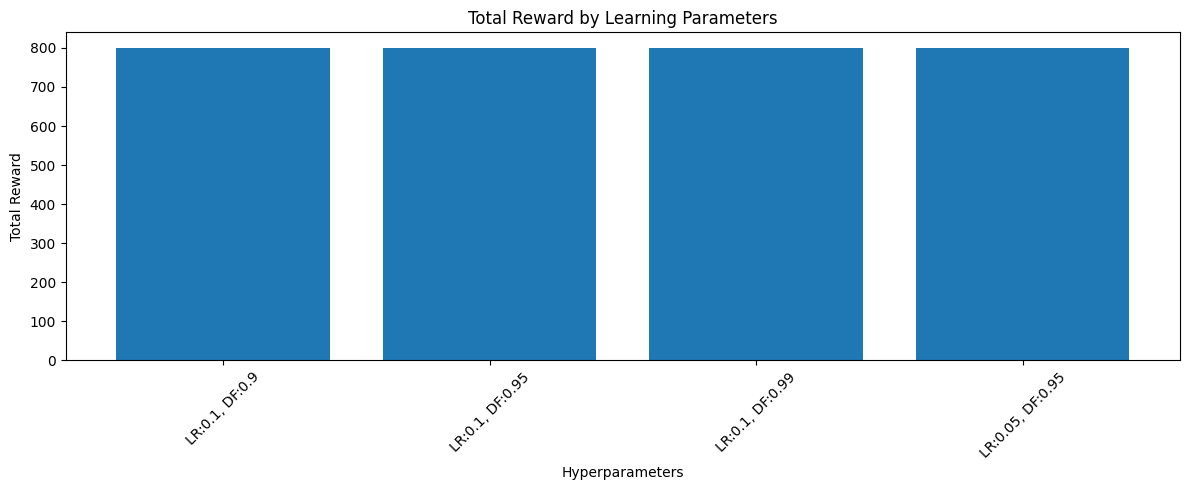

Params: {'learning_rate': 0.1, 'discount_factor': 0.9}, Total Reward: 800.0
Params: {'learning_rate': 0.1, 'discount_factor': 0.95}, Total Reward: 800.0
Params: {'learning_rate': 0.1, 'discount_factor': 0.99}, Total Reward: 800.0
Params: {'learning_rate': 0.05, 'discount_factor': 0.95}, Total Reward: 800.0


In [3]:
def compare_agent_strategies(hyperparameter_grid):
    """
    Compare different agent learning strategies
    
    Args:
        hyperparameter_grid (list): List of hyperparameter configurations
    
    Returns:
        list: Results of different strategies
    """
    results = []
    
    for params in hyperparameter_grid:
        # Create environment
        env = ScarseGridEnv()
        
        # Create multi-agent trainer with specific hyperparameters
        multi_agent_trainer = MultiAgentQLearning(
            env,
            learning_rate=params['learning_rate'],
            discount_factor=params['discount_factor']
        )
        
        # Train agents
        agent_rewards = multi_agent_trainer.train(num_episodes=50)
        
        # Compute total reward
        total_reward = np.sum([np.sum(rewards) for rewards in agent_rewards])
        
        results.append({
            'params': params,
            'total_reward': total_reward
        })
    
    return results

# Hyperparameter Grid
hyperparameter_grid = [
    {'learning_rate': 0.1, 'discount_factor': 0.9},
    {'learning_rate': 0.1, 'discount_factor': 0.95},
    {'learning_rate': 0.1, 'discount_factor': 0.99},
    {'learning_rate': 0.05, 'discount_factor': 0.95}
]

# Run strategy comparison
strategy_results = compare_agent_strategies(hyperparameter_grid)

# Visualize Results
plt.figure(figsize=(12, 5))
plt.bar(
    [f"LR:{params['learning_rate']}, DF:{params['discount_factor']}" for params in hyperparameter_grid],
    [result['total_reward'] for result in strategy_results]
)
plt.title('Total Reward by Learning Parameters')
plt.xlabel('Hyperparameters')
plt.ylabel('Total Reward')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print detailed results
for result in strategy_results:
    print(f"Params: {result['params']}, Total Reward: {result['total_reward']}")
